In [8]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Lotka-Volterra

In [9]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)
true_coeffs = generate_lotka_volterra_true_coefficients(1, 0.1, 1.5, 0.75)


noise_levels = np.logspace(-3, 0, 10).tolist()
thresholds = np.linspace(0.001, 0.2, 11).tolist()

t_span = (0, 50)

# if a parameter is a list, the experiment will be run for each combination of the parameters
# if a parameter is not a list, the same value will be used for all experiments
# the first list will be the rows and the second list will be the columns
experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
    # define parameters that can be lists
    'x0': (10, 5),
    'noise_level': noise_levels,
    't_eval_train': None, 'dt_train': 0.01, 't_span_train': t_span,
    'threshold': thresholds,
    'poly_order': 5,
    'n_frequencies': 0,
    # define parameters that are used after the experiment
    'true_coeffs': true_coeffs
}

results = run_experiment(experiment_config)

rows are noise_level. there are 10 rows.
columns are threshold. there are 11 columns.
step 1 of 10


 45%|████▌     | 5/11 [00:06<00:07,  1.27s/it]c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:9: RuntimeWarning: overflow encountered in power
  return lambda x: np.prod(np.power(x, power_tuple), axis=1)
c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:142: RuntimeWarning: invalid value encountered in matmul
  x_dot = Theta @ self.Xi
c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  solver._y, solver.t = integrator.run(
100%|██████████| 11/11 [00:12<00:00,  1.13s/it]


step 2 of 10


100%|██████████| 11/11 [00:14<00:00,  1.29s/it]


step 3 of 10


...

100%|██████████| 11/11 [00:12<00:00,  1.13s/it]


step 9 of 10


100%|██████████| 11/11 [00:24<00:00,  2.23s/it]


step 10 of 10


100%|██████████| 11/11 [00:04<00:00,  2.30it/s]


rows are noise_level. there are 10 rows.
columns are threshold. there are 11 columns.


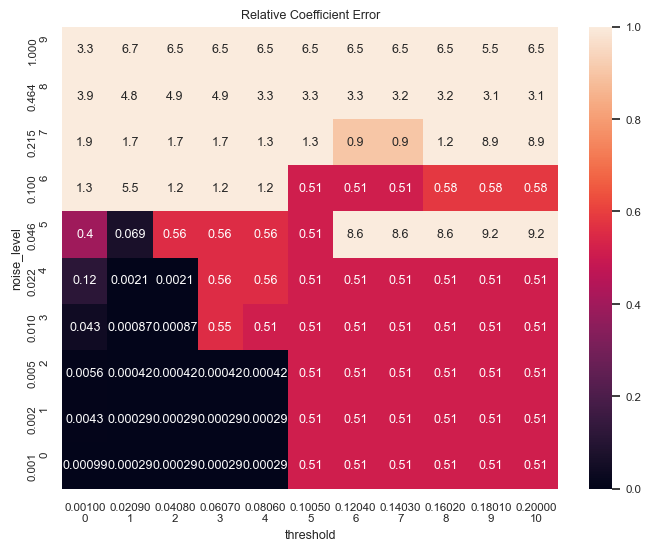

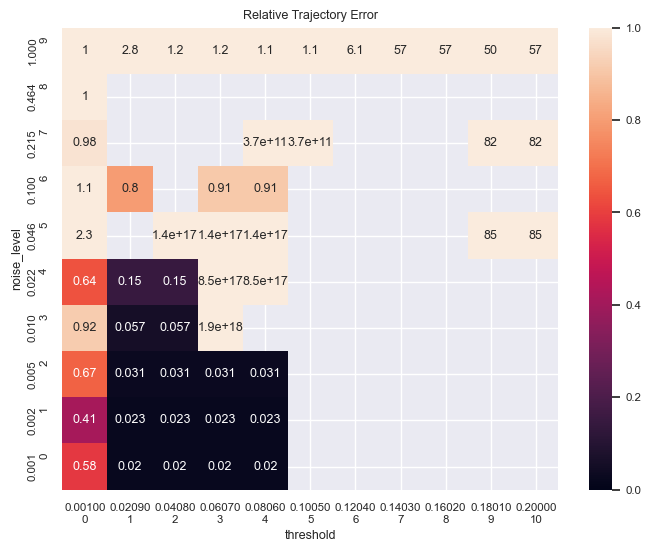

In [10]:
plot_heatmaps(experiment_config, results)

In [11]:
# display_single_result(experiment_config, results, 3, 2, keys_to_display=['x_test', 'x_pred', 'x_train'])